<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

### Random Forest Classification — Required Steps

1. **Import the required libraries**

   * Pandas
   * Visualization libraries
   * Scikit-learn preprocessing, pipeline, Random Forest, and evaluation tools

2. **Load the `car_insurance.csv` dataset**

   * Display the first few rows.

3. **Explore the dataset**

   * Check `shape`, `info()`, and `describe()`.
   * Check for missing values.
   * Identify numerical and categorical columns.
   * Visualize the `outcome` target distribution.

4. **Prepare features and target**

   * Create `X` containing the input features.
   * Create `y` containing `outcome`.
   * Decide whether the `id` column should be removed.

5. **Identify feature types**

   * Numerical
   * Categorical
   * Ordinal, where appropriate

6. **Preprocess the features**

   * Apply suitable encoding/transformation.
   * Organize preprocessing using `ColumnTransformer`.

7. **Split the data**

   * 80% training data.
   * 20% testing data.
   * Use `random_state`.

8. **Create a machine learning `Pipeline`**

   * Combine the `ColumnTransformer` preprocessing with `RandomForestClassifier`.

9. **Train the Random Forest**

   * Fit the pipeline using `X_train` and `y_train`.

10. **Make predictions**

    * Predict `X_test`.
    * Store the result as `y_pred`.

11. **Evaluate the model**

    * Accuracy
    * Confusion Matrix
    * Precision
    * Recall
    * F1-score
    * Classification Report

12. **Write a conclusion**

    * Explain the preprocessing performed.
    * State the model's performance.
    * Interpret the evaluation metrics.
    * Conclude how well the Random Forest predicts insurance claims.

**Overall workflow:**

`Explore → Prepare X/y → Preprocess → Split → Pipeline → Random Forest → Train → Predict → Evaluate → Conclusion`

In [1]:
# Import required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ML libraries
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder , RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# Start coding!

In [2]:
df =pd.read_csv("car_insurance.csv")

In [3]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [4]:
df.isnull().sum()

id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

3. **Explore the dataset**

   * Check `shape`, `info()`, and `describe()`.
   * Check for missing values.
   * Identify numerical and categorical columns.
   * Visualize the `outcome` target distribution.


In [5]:
print(f"Dataframe shape: {df.shape}")
print(f"\n{'='*50}\n")
print(f"DataFrame info:\n{df.info}")
print(f"\n{'='*50}\n")
print(f"DataFrame describe:\n{df.describe()}")

Dataframe shape: (10000, 18)


DataFrame info:
<bound method DataFrame.info of           id  age  gender driving_experience    education         income  \
0     569520    3       0               0-9y  high school    upper class   
1     750365    0       1               0-9y         none        poverty   
2     199901    0       0               0-9y  high school  working class   
3     478866    0       1               0-9y   university  working class   
4     731664    1       1             10-19y         none  working class   
...      ...  ...     ...                ...          ...            ...   
9995  323164    1       0             10-19y   university    upper class   
9996  910346    1       0             10-19y         none   middle class   
9997  468409    1       1               0-9y  high school   middle class   
9998  903459    1       0             10-19y  high school        poverty   
9999  442696    1       0               0-9y         none  working class   

      cr

In [6]:
# Filling missing data
df['credit_score'] = df.credit_score.fillna(df['credit_score'].median())
df.credit_score.isna().sum()

df['annual_mileage'] = df.annual_mileage.fillna(df.annual_mileage.median())
df.isna().sum()

id                     0
age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
postal_code            0
annual_mileage         0
vehicle_type           0
speeding_violations    0
duis                   0
past_accidents         0
outcome                0
dtype: int64

In [7]:
df.dtypes

id                       int64
age                      int64
gender                   int64
driving_experience      object
education               object
income                  object
credit_score           float64
vehicle_ownership      float64
vehicle_year            object
married                float64
children               float64
postal_code              int64
annual_mileage         float64
vehicle_type            object
speeding_violations      int64
duis                     int64
past_accidents           int64
outcome                float64
dtype: object

In [8]:
df.outcome.value_counts()

outcome
0.0    6867
1.0    3133
Name: count, dtype: int64

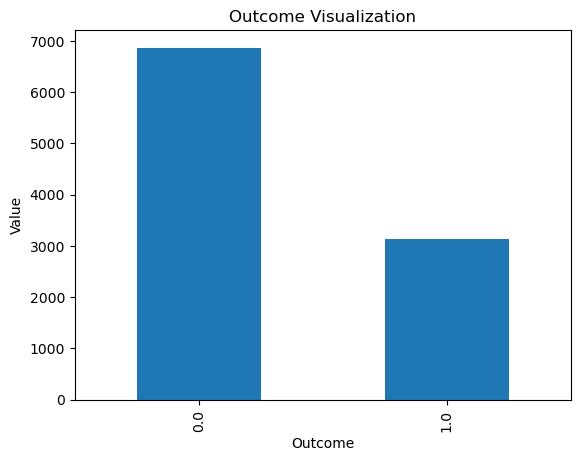

In [9]:
df.outcome.value_counts().plot(kind='bar')

plt.title('Outcome Visualization')
plt.xlabel('Outcome')
plt.ylabel('Value')
plt.show()

4. **Prepare features and target**

   * Create `X` containing the input features.
   * Create `y` containing `outcome`.
   * Decide whether the `id` column should be removed.

In [10]:
df.columns

Index(['id', 'age', 'gender', 'driving_experience', 'education', 'income',
       'credit_score', 'vehicle_ownership', 'vehicle_year', 'married',
       'children', 'postal_code', 'annual_mileage', 'vehicle_type',
       'speeding_violations', 'duis', 'past_accidents', 'outcome'],
      dtype='object')

In [11]:
X= df.drop(['id' , 'outcome'], axis = 1)
y= df['outcome']

5. **Identify feature types**

   * Numerical
   * Categorical
   * Ordinal, where appropriate


In [12]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

In [13]:
num_cols, cat_cols

(['age',
  'gender',
  'credit_score',
  'vehicle_ownership',
  'married',
  'children',
  'postal_code',
  'annual_mileage',
  'speeding_violations',
  'duis',
  'past_accidents'],
 ['driving_experience', 'education', 'income', 'vehicle_year', 'vehicle_type'])

In [14]:
num_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('rbs', RobustScaler())
])

cat_trans = Pipeline(steps=[
    ('ode', OrdinalEncoder())
])

In [15]:
num_trans

,steps,"[('imputer', ...), ('rbs', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [16]:
cat_trans

,steps,"[('ode', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


6. **Preprocess the features**

   * Apply suitable encoding/transformation.
   * Organize preprocessing using `ColumnTransformer`.

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_trans, num_cols),
    ('cat', cat_trans, cat_cols)
])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


7. **Split the data**

   * 80% training data.
   * 20% testing data.
   * Use `random_state`.

In [18]:
X_train, X_test , y_train , y_test = train_test_split(X,y,
                                                      test_size=0.2,
                                                      random_state=12)

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  int64  
 1   gender               10000 non-null  int64  
 2   driving_experience   10000 non-null  object 
 3   education            10000 non-null  object 
 4   income               10000 non-null  object 
 5   credit_score         10000 non-null  float64
 6   vehicle_ownership    10000 non-null  float64
 7   vehicle_year         10000 non-null  object 
 8   married              10000 non-null  float64
 9   children             10000 non-null  float64
 10  postal_code          10000 non-null  int64  
 11  annual_mileage       10000 non-null  float64
 12  vehicle_type         10000 non-null  object 
 13  speeding_violations  10000 non-null  int64  
 14  duis                 10000 non-null  int64  
 15  past_accidents       10000 non-null  

In [20]:
X_train.shape, X_test.shape

((8000, 16), (2000, 16))

In [21]:
# clf= DecisionTreeClassifier()
# clf

In [22]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [23]:
df.income.value_counts()

income
upper class      4336
middle class     2138
poverty          1814
working class    1712
Name: count, dtype: int64

In [24]:
cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('ohe',OrdinalEncoder(handle_unknown='ignore')),
])
cat_trans

,steps,"[('imputer', ...), ('ohe', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'constant'
,fill_value,'missing'
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


8. **Create a machine learning `Pipeline`**

   * Combine the `ColumnTransformer` preprocessing with `RandomForestClassifier`.


In [25]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
full_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


9. **Train the Random Forest**

   * Fit the pipeline using `X_train` and `y_train`.


In [26]:
X_train.shape

(8000, 16)

In [27]:
y_train.shape

(8000,)

In [28]:
full_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


10. **Make predictions**

    * Predict `X_test`.
    * Store the result as `y_pred`.


In [29]:
y_pred = full_pipeline.predict(X_test)
y_pred

array([0., 0., 0., ..., 1., 0., 1.], shape=(2000,))

11. **Evaluate the model**

    * Accuracy
    * Confusion Matrix
    * Precision
    * Recall
    * F1-score
    * Classification Report

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mae

0.159

In [31]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1238,  130],
       [ 188,  444]])

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.90      0.89      1368
         1.0       0.77      0.70      0.74       632

    accuracy                           0.84      2000
   macro avg       0.82      0.80      0.81      2000
weighted avg       0.84      0.84      0.84      2000



12. **Write a conclusion**

    * Explain the preprocessing performed.
    * State the model's performance.
    * Interpret the evaluation metrics.
    * Conclude how well the Random Forest predicts insurance claims.


Question 1

During preprocessing, the dataset was first split into two groups: Categorical columns (cat_cols) and Numerical columns (num_cols). Following this separation, RobustScaler was applied to handle the numerical features, while OrdinalEncoder was used to transform the categorical features.

Question 2

The model recorded an accuracy score of 83%.

Question 3

Accuracy (83%): The model correctly classified 83% of all cases in the dataset.
Precision (class 1): Out of all instances the model labeled as class 1, 76% were correct predictions.
Recall (class 1): The model successfully identified 69% of all true class-1 instances.
F1-score (class 1): At 72%, this reflects a reasonably balanced trade-off between precision and recall for class 1.

Question 4

In summary, the RandomForest model performs fairly well at predicting insurance claims, achieving an accuracy of 83%. This indicates the model is generally reliable in identifying claim outcomes correctly, though there remains room for improvement since a portion of predictions are still inaccurate.

## Your Task 
## update your existing car insurance case study
- save the model using joblib
- load the model and test it with a simple data (check if the model is working)
- create a gradio demo (please explore the documentation to make it your own)
- push to github

In [37]:
import joblib
from pathlib import Path

MODEL_PATH = "car_insurance_model.joblib"
bundle = {
    "model" : full_pipeline,
    "labels" : ["No Claim" , "Claim"]
}
joblib.dump(bundle , MODEL_PATH) 
print(Path(MODEL_PATH).stat().st_size, "bytes saved")

22423212 bytes saved


In [38]:
bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
LABELS = bundle["labels"]
FEATURES = list(model.feature_names_in_)   # the 16 columns the pipeline expects

def predict_claims(data):
    df = pd.read_csv(data) if isinstance(data, str) else data.copy()

    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"Input is missing required column(s): {missing}")

    X_new = df[FEATURES]
    proba = model.predict_proba(X_new)

    output = df.copy()
    output["predicted_class"] = [LABELS[i] for i in proba.argmax(axis=1)]
    output["confidence"] = proba.max(axis=1)
    return output

In [39]:
_check = predict_claims(X_test.head(20))
_expected = model.predict(X_test.head(20))
print(_check)
assert (_check["predicted_class"].map({"No Claim": 0, "Claim": 1}).values == _expected).all()
print("Sanity check passed — loaded model matches original pipeline predictions.")

      age  gender driving_experience    education         income  \
5669    2       0             20-29y  high school    upper class   
8800    0       0               0-9y         none        poverty   
3205    1       1             10-19y  high school  working class   
8731    2       0             20-29y  high school    upper class   
6412    0       0               0-9y   university   middle class   
6828    1       1             10-19y  high school   middle class   
5795    1       1               0-9y  high school    upper class   
9617    2       0             20-29y  high school   middle class   
4643    2       1             20-29y  high school   middle class   
1844    2       1             20-29y         none    upper class   
7947    2       1             20-29y   university    upper class   
6792    2       1               0-9y  high school    upper class   
1237    2       0               0-9y         none  working class   
5974    0       0               0-9y         non

In [40]:
(_check["predicted_class"].map({"No Claim": 0, "Claim": 1}).values == _expected).all()

np.True_

In [44]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [47]:
! pip install gradio 

In [49]:
for f in ["age", "driving_experience", "education", "income", "vehicle_year", "vehicle_type", "gender", "married", "vehicle_ownership"]:
    print(f, "->", df[f].unique())

age -> [3 0 1 2]
driving_experience -> ['0-9y' '10-19y' '20-29y' '30y+']
education -> ['high school' 'none' 'university']
income -> ['upper class' 'poverty' 'working class' 'middle class']
vehicle_year -> ['after 2015' 'before 2015']
vehicle_type -> ['sedan' 'sports car']
gender -> [0 1]
married -> [0. 1.]
vehicle_ownership -> [1. 0.]


In [52]:
import gradio as gr

# Columns that should be dropdowns (categorical / coded)
CATEGORICAL_FEATURES = [
    "age", "gender", "driving_experience", "education", "income",
    "vehicle_ownership", "vehicle_year", "married", "vehicle_type"
]

# Build choices straight from the actual training data — no manual guessing
DROPDOWN_CHOICES = {
    f: sorted(X_train[f].dropna().unique().tolist(), key=str)
    for f in CATEGORICAL_FEATURES
}

DEFAULTS = X_train.iloc[0][FEATURES].to_dict()

def classify(*values):
    row = pd.DataFrame([dict(zip(FEATURES, values))])
    proba = model.predict_proba(row)[0]
    return {label: float(p) for label, p in zip(LABELS, proba)}

def build_input(feature):
    if feature in DROPDOWN_CHOICES:
        return gr.Dropdown(choices=DROPDOWN_CHOICES[feature], value=DEFAULTS[feature], label=feature)
    else:
        return gr.Number(label=feature, value=DEFAULTS[feature])

demo = gr.Interface(
    fn=classify,
    inputs=[build_input(f) for f in FEATURES],
    outputs=gr.Label(num_top_classes=2, label="Claim Prediction"),
    title="Car Insurance Claim Predictor",
    description="Random Forest pipeline predicting whether a customer will file a claim."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
